In [1]:
from typing import List, Literal
from typing_extensions import TypedDict

from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

from models import get_model, get_embeddings
from pdf_chunk import text_spliter

e:\Rohanta_AI_workbook\adavance_RAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm             = get_model()
embedding_model = get_embeddings()
web_search      = DuckDuckGoSearchRun()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1680.04it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
vectorstore = Chroma.from_documents(
    text_spliter,
    embedding_model,
    collection_name="agentic_rag"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

In [4]:
class AgenticRAGState(TypedDict):
    question        : str
    documents       : List[Document]
    generation      : str
    web_search      : str    # "yes" | "no"
    retry_count     : int    # safety counter to avoid infinite loops

In [5]:
router_prompt = ChatPromptTemplate.from_template("""
You are a routing expert. Decide where to retrieve information.

- Use "vectorstore" for questions about Rohanta's resume, career,
  skills, education, projects, or personal background.
- Use "web_search" for questions about current events, latest news,
  new software versions, or anything not in a personal profile.

Return ONLY one word: "vectorstore" or "web_search".

Question: {question}
Route:
""")

In [6]:
router_chain = router_prompt | llm | StrOutputParser()

In [7]:
grader_prompt = ChatPromptTemplate.from_template("""
Does this document contain information useful for answering the question?
Answer ONLY "yes" or "no".

Question: {question}
Document: {document}
Score:
""")

In [8]:
grader_chain = grader_prompt | llm | StrOutputParser()


In [9]:
rewriter_prompt = ChatPromptTemplate.from_template("""
Rewrite this question to improve retrieval results.
Output ONLY the rewritten question, nothing else.

Original: {question}
Rewritten:
""")

In [10]:
rewriter_chain = rewriter_prompt | llm | StrOutputParser()

In [11]:
answer_prompt = ChatPromptTemplate.from_template("""
Answer the question using only the context provided.
Be concise and factual. If the answer is not in the context, say "I don't know".

Context: {context}
Question: {question}
Answer:
""")

In [12]:
answer_chain = answer_prompt | llm | StrOutputParser()

In [13]:
hallucination_prompt = ChatPromptTemplate.from_template("""
You are checking if an answer is grounded in the provided documents.
Is the answer based on facts from the documents? No made-up information?
Answer ONLY "yes" (grounded) or "no" (hallucinating).

Documents: {documents}
Answer: {generation}
Score:
""")

In [14]:
hallucination_chain = hallucination_prompt | llm | StrOutputParser()

In [15]:
quality_prompt = ChatPromptTemplate.from_template("""
Does this answer actually address the question asked?
Answer ONLY "yes" (useful) or "no" (not useful).

Question: {question}
Answer: {generation}
Score:
""")

In [16]:
quality_chain = quality_prompt | llm | StrOutputParser()

In [17]:
def route_question(state: AgenticRAGState) -> dict:
    """Node: decide vectorstore vs web search."""
    print("\n--- NODE: route_question ---")
    route = router_chain.invoke({"question": state["question"]}).strip().lower()
    print(f"  Route → {route}")
    # Store routing decision in web_search flag
    web = "yes" if "web" in route else "no"
    return {"web_search": web, "retry_count": state.get("retry_count", 0)}

In [18]:
def retrieve(state: AgenticRAGState) -> dict:
    """Node: retrieve from Chroma."""
    print("--- NODE: retrieve ---")
    docs = retriever.invoke(state["question"])
    print(f"  Retrieved {len(docs)} docs")
    return {"documents": docs}


In [19]:
def web_search_node(state: AgenticRAGState) -> dict:
    """Node: search the web."""
    print("--- NODE: web_search ---")
    results = web_search.invoke(state["question"])
    web_doc = Document(
        page_content=results,
        metadata={"source": "web", "type": "web_search"}
    )
    return {"documents": [web_doc]}

In [20]:
def grade_documents(state: AgenticRAGState) -> dict:
    """Node: grade each doc for relevance."""
    print("--- NODE: grade_documents ---")
    question     = state["question"]
    docs         = state["documents"]
    relevant     = []
    needs_web    = "no"

    for doc in docs:
        score = grader_chain.invoke({
            "question": question,
            "document": doc.page_content
        }).strip().lower()

        if "yes" in score:
            relevant.append(doc)
            print(f"  RELEVANT   : {doc.page_content[:55]}...")
        else:
            needs_web = "yes"
            print(f"  IRRELEVANT : {doc.page_content[:55]}...")

    return {"documents": relevant, "web_search": needs_web}

In [21]:
def rewrite_query(state: AgenticRAGState) -> dict:
    """Node: rewrite the query for a better retry."""
    print("--- NODE: rewrite_query ---")
    rewritten = rewriter_chain.invoke({"question": state["question"]}).strip()
    print(f"  Rewritten: {rewritten}")
    return {
        "question"   : rewritten,
        "retry_count": state.get("retry_count", 0) + 1
    }

In [22]:
def generate(state: AgenticRAGState) -> dict:
    """Node: generate the answer."""
    print("--- NODE: generate ---")
    context = "\n\n".join([d.page_content for d in state["documents"]])
    answer  = answer_chain.invoke({
        "question": state["question"],
        "context" : context
    })
    print(f"  Generated: {answer[:80]}...")
    return {"generation": answer}

In [23]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Conditional edge functions
# ════════════════════════════════════════════════════════════════
MAX_RETRIES = 3

def decide_retrieval_path(state: AgenticRAGState) -> Literal["retrieve", "web_search"]:
    """After router: which retrieval path?"""
    if state.get("web_search") == "yes":
        return "web_search"
    return "retrieve"


def decide_after_grading(
    state: AgenticRAGState
) -> Literal["rewrite_query", "generate"]:
    """After grading: enough relevant docs or rewrite?"""
    if state.get("web_search") == "yes":
        if state.get("retry_count", 0) >= MAX_RETRIES:
            print("  MAX RETRIES reached → forcing generate")
            return "generate"
        return "rewrite_query"
    return "generate"


def decide_after_hallucination(
    state: AgenticRAGState
) -> Literal["generate", "answer_grader"]:
    """After hallucination check: re-generate or check quality?"""
    docs       = "\n\n".join([d.page_content for d in state["documents"]])
    generation = state["generation"]
    score = hallucination_chain.invoke({
        "documents" : docs,
        "generation": generation
    }).strip().lower()

    print(f"--- EDGE: hallucination check → {score} ---")

    if "yes" in score:
        return "answer_grader"      # grounded → check quality
    else:
        if state.get("retry_count", 0) >= MAX_RETRIES:
            return "answer_grader"  # give up retrying
        return "generate"           # hallucinating → re-generate


def decide_after_quality(
    state: AgenticRAGState
) -> Literal["rewrite_query", END]:
    """After quality check: useful answer or rewrite from scratch?"""
    score = quality_chain.invoke({
        "question"  : state["question"],
        "generation": state["generation"]
    }).strip().lower()

    print(f"--- EDGE: quality check → {score} ---")

    if "yes" in score:
        return END                  # ✓ done
    else:
        if state.get("retry_count", 0) >= MAX_RETRIES:
            return END              # give up
        return "rewrite_query"      # not useful → rewrite + retry

In [24]:
builder = StateGraph(AgenticRAGState)

In [25]:
builder.add_node("router",          route_question)
builder.add_node("retrieve",        retrieve)
builder.add_node("web_search",      web_search_node)
builder.add_node("grade_documents", grade_documents)
builder.add_node("rewrite_query",   rewrite_query)
builder.add_node("generate",        generate)
builder.add_node("answer_grader",   lambda s: s)  # pass-through for edge logic

In [26]:
builder.add_edge(START,            "router")
builder.add_edge("retrieve",       "grade_documents")
builder.add_edge("web_search",     "grade_documents")
builder.add_edge("rewrite_query",  "router")        # retry loops back to router
builder.add_edge("generate",       "answer_grader")

In [27]:
builder.add_conditional_edges(
    "router",
    decide_retrieval_path,
    {"retrieve": "retrieve", "web_search": "web_search"}
)

builder.add_conditional_edges(
    "grade_documents",
    decide_after_grading,
    {"rewrite_query": "rewrite_query", "generate": "generate"}
)

builder.add_conditional_edges(
    "answer_grader",
    decide_after_quality,
    {"rewrite_query": "rewrite_query", END: END}
)

In [28]:
memory        = MemorySaver()
agentic_graph = builder.compile(checkpointer=memory)

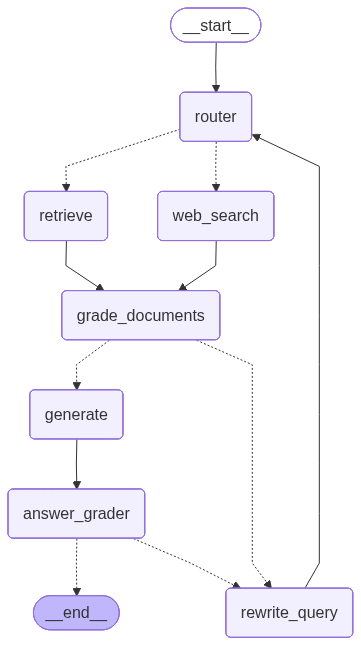

In [29]:
agentic_graph

In [30]:
def run_agentic_rag(question: str, thread_id: str = "default") -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = agentic_graph.invoke(
        {"question": question, "retry_count": 0},
        config=config
    )
    return result.get("generation", "No answer generated.")

In [31]:
print(run_agentic_rag("What is Rohanta's current university?"))


--- NODE: route_question ---
  Route → vectorstore
--- NODE: retrieve ---
  Retrieved 4 docs
--- NODE: grade_documents ---
  IRRELEVANT : Before transitioning fully into industry, Rohanta taugh...
  IRRELEVANT : Rohanta Bhamare is an AI Engineer with 5+ years of expe...
  IRRELEVANT : Role: Assistant Professor
Institution: Guru Gobind Sing...
  IRRELEVANT : IDENTITY AND CONTACT

Full Name: Rohanta Dinkar Bhamare...
--- NODE: rewrite_query ---
  Rewritten: What is the current university that Rohanta is attending?

--- NODE: route_question ---
  Route → vectorstore
--- NODE: retrieve ---
  Retrieved 4 docs
--- NODE: grade_documents ---
  IRRELEVANT : Before transitioning fully into industry, Rohanta taugh...
  IRRELEVANT : Rohanta Bhamare is an AI Engineer with 5+ years of expe...
  IRRELEVANT : Role: Assistant Professor
Institution: Guru Gobind Sing...
  IRRELEVANT : Rohanta is looking for full-time roles as an ML Enginee...
--- NODE: rewrite_query ---
  Rewritten: What is the current 

In [32]:
print(run_agentic_rag("What is the latest LangGraph release in 2025?"))


--- NODE: route_question ---
  Route → web_search
--- NODE: web_search ---
--- NODE: grade_documents ---
  RELEVANT   : ...2025showcase! This month featured cutting-edge prese...
--- NODE: generate ---
  Generated: LangGraph v0.1...
--- EDGE: quality check → no ---
--- NODE: rewrite_query ---
  Rewritten: What is the latest version or update of LangGraph released in 2025?

--- NODE: route_question ---
  Route → web_search
--- NODE: web_search ---
--- NODE: grade_documents ---
  RELEVANT   : In October2025,LangGraphreachedversion1.0, becoming the...
--- NODE: generate ---
  Generated: I don't know....
--- EDGE: quality check → no ---
--- NODE: rewrite_query ---
  Rewritten: What is the most recent version or update of LangGraph that was released in 2025 or has a release date in 2025?

--- NODE: route_question ---
  Route → web_search
--- NODE: web_search ---
--- NODE: grade_documents ---
  RELEVANT   : LangGraph1.0 is now generally availableLangGraph1.0 is ...
--- NODE: generate ---
  

In [33]:
print(run_agentic_rag("What advanced AI work has Rohanta published?"))


--- NODE: route_question ---
  Route → vectorstore
--- NODE: retrieve ---
  Retrieved 4 docs
--- NODE: grade_documents ---
  RELEVANT   : Rohanta Bhamare is an AI Engineer with 5+ years of expe...
  RELEVANT   : reasoning. Rohanta actively experiments with state mana...
  RELEVANT   : Before transitioning fully into industry, Rohanta taugh...
  RELEVANT   : Rohanta is looking for full-time roles as an ML Enginee...
--- NODE: generate ---
  Generated: I don't know....
--- EDGE: quality check → no ---
--- NODE: rewrite_query ---
  Rewritten: What notable or significant AI research or publications has Rohanta contributed to or released?

--- NODE: route_question ---
  Route → vectorstore
--- NODE: retrieve ---
  Retrieved 4 docs
--- NODE: grade_documents ---
  IRRELEVANT : Before transitioning fully into industry, Rohanta taugh...
  IRRELEVANT : Rohanta Bhamare is an AI Engineer with 5+ years of expe...
  IRRELEVANT : Rohanta is looking for full-time roles as an ML Enginee...
  IRRELEVAN